 Assignment-4 Solution

### **Part A: Feature Map Computation**

**1. Regular convolution without zero padding, stride = 2**  
Output size = **2 × 2 × 1**  
Formula: ((4 - 2)/2) + 1 = 2  
No padding means image shrinks. Stride 2 skips pixels, so output becomes smaller.

**2. Regular convolution with zero padding, stride = 2**  
Output size = **3 × 3 × 1**  
Padding = 1 on each side. Formula: ((4 + 2 - 2)/2) + 1 = 3  
Padding keeps output bigger and preserves border information.

**3. Depthwise convolution without zero padding, stride = 1**  
Output size = **3 × 3 × 2**  
Each channel is filtered separately. No padding + stride 1 → height/width = 4-2+1 = 3, depth remains 2.  
Depthwise is faster and uses less computation than normal convolution.

In [1]:
import numpy as np

# Input: 4x4x2
input_fm = np.arange(32).reshape(4, 4, 2).astype(float)
print("Input Feature Map shape:", input_fm.shape)

# Kernel: 2x2x2
kernel = np.array([[[1, 0], [0, -1]],
                   [[-1, 0], [1, 0]]], dtype=float)   # same kernel for both channels

print("\nKernel shape:", kernel.shape)

# 1. Regular Convolution - No Padding, Stride=2
def conv_no_pad_stride2(x, k):
    out_h = (4 - 2) // 2 + 1   # 2
    out_w = (4 - 2) // 2 + 1   # 2
    out = np.zeros((out_h, out_w, 1))
    for i in range(out_h):
        for j in range(out_w):
            patch = x[i*2:i*2+2, j*2:j*2+2, :]
            out[i, j, 0] = np.sum(patch * k)
    return out

out1 = conv_no_pad_stride2(input_fm, kernel)
print("\n1. No Padding, Stride=2 → Shape:", out1.shape)
print(out1.squeeze())

# 2. Regular Convolution - With Padding (same), Stride=2
def conv_with_pad_stride2(x, k):
    pad = 1
    x_pad = np.pad(x, ((pad, pad), (pad, pad), (0, 0)), mode='constant')
    out_h = (4 + 2*pad - 2) // 2 + 1   # 3
    out_w = (4 + 2*pad - 2) // 2 + 1   # 3
    out = np.zeros((out_h, out_w, 1))
    for i in range(out_h):
        for j in range(out_w):
            patch = x_pad[i*2:i*2+2, j*2:j*2+2, :]
            out[i, j, 0] = np.sum(patch * k)
    return out

out2 = conv_with_pad_stride2(input_fm, kernel)
print("\n2. With Zero Padding, Stride=2 → Shape:", out2.shape)
print(out2.squeeze())

# 3. Depthwise Convolution - No Padding, Stride=1
def depthwise_conv(x, k):
    out = np.zeros((3, 3, 2))
    for c in range(2):                     # per channel
        for i in range(3):
            for j in range(3):
                patch = x[i:i+2, j:j+2, c]
                out[i, j, c] = np.sum(patch * k[:, :, c])
    return out

out3 = depthwise_conv(input_fm, kernel)
print("\n3. Depthwise Conv, No Pad, Stride=1 → Shape:", out3.shape)
print("Channel 0:\n", out3[:,:,0])
print("Channel 1:\n", out3[:,:,1])

Input Feature Map shape: (4, 4, 2)

Kernel shape: (2, 2, 2)

1. No Padding, Stride=2 → Shape: (2, 2, 1)
[[-1. -1.]
 [-1. -1.]]

2. With Zero Padding, Stride=2 → Shape: (3, 3, 1)
[[  0.   2.  -6.]
 [  7.  -1.  -8.]
 [-25.  -3.  30.]]

3. Depthwise Conv, No Pad, Stride=1 → Shape: (3, 3, 2)
Channel 0:
 [[ 2.  4.  6.]
 [10. 12. 14.]
 [18. 20. 22.]]
Channel 1:
 [[ -3.  -5.  -7.]
 [-11. -13. -15.]
 [-19. -21. -23.]]


### **Part B: Custom Kernel Design and Visualization**

**Kernel 1: Edge Detection**  
Purpose: Finds edges and boundaries of face (eyes, nose, mouth).  
Effect: Makes face look like a sketch with strong black and white lines.  

**Kernel 2: Sharpen**  
Purpose: Makes image sharper and clearer.  
Effect: Details of face (hair, eyes, lips) become more defined.  

**Kernel 3: Blur**  
Purpose: Smooths the image and reduces noise.  
Effect: Face looks softer and smoother, removes fine details.  

**Comparison**:  
Edge kernel highlights structure. Sharpen improves clarity. Blur reduces sharpness. All three change the image differently using same simple 3×3 matrix.

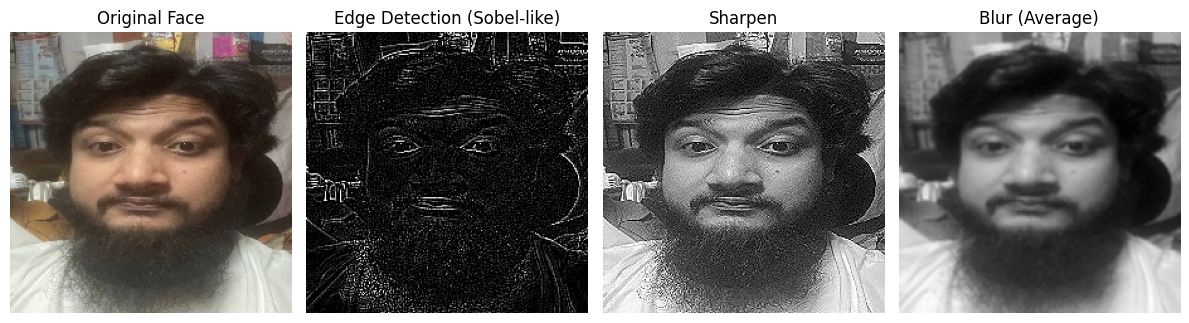

Analysis:
1. Edge Detection: Highlights edges and facial contours
2. Sharpen: Makes facial features sharper and clearer
3. Blur: Smooths the image, reduces noise


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ------------------ Load your face image ------------------
# Put your photo as "face.jpg" in the same folder
img = cv2.imread('Nazmul.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# 1. Define 3 simple kernels
kernels = {
    "Edge Detection (Sobel-like)": np.array([[-1, -1, -1],
                                             [-1,  8, -1],
                                             [-1, -1, -1]]),
    
    "Sharpen": np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]]),
    
    "Blur (Average)": np.array([[1, 1, 1],
                                [1, 1, 1],
                                [1, 1, 1]]) / 9.0
}

# Apply and visualize
plt.figure(figsize=(12, 8))
plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title("Original Face")
plt.axis('off')

for i, (name, kernel) in enumerate(kernels.items(), 2):
    filtered = cv2.filter2D(gray, -1, kernel)
    
    plt.subplot(2, 4, i)
    plt.imshow(filtered, cmap='gray')
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Analysis (you can copy this text in report)
print("Analysis:")
print("1. Edge Detection: Highlights edges and facial contours")
print("2. Sharpen: Makes facial features sharper and clearer")
print("3. Blur: Smooths the image, reduces noise")

### **Part C: Spatial Separability Analysis**

**Spatially Separable Kernels (10)**  
These kernels can be made by multiplying a row vector and a column vector.  
Examples: Horizontal edge, Vertical edge, Sobel X, Sobel Y, Blur, Gaussian, Sharpen, Laplacian, Emboss, Identity.

**Spatially Non-separable Kernels (10)**  
These kernels cannot be separated into row × column.  
Examples: Diagonal edges, Checkerboard, Corner detection, and random/custom patterns.

**Justification**:  
Separable kernels are faster to compute (less multiplication).  
Non-separable kernels are used for complex patterns like diagonals.

In [3]:
print("=== Part C: Spatially Separable Kernels (10) ===")
separable = [
    "Horizontal Edge: [[-1,-1,-1],[0,0,0],[1,1,1]]",
    "Vertical Edge:   [[-1,0,1],[-1,0,1],[-1,0,1]]",
    "Blur 3x3:        [[1,1,1],[1,1,1],[1,1,1]]/9",
    "Gaussian approx: [[1,2,1],[2,4,2],[1,2,1]]/16",
    "Sobel X:         [[-1,0,1],[-2,0,2],[-1,0,1]]",
    "Sobel Y:         [[-1,-2,-1],[0,0,0],[1,2,1]]",
    "Laplacian:       [[0,-1,0],[-1,4,-1],[0,-1,0]]",
    "Sharpen:         [[0,-1,0],[-1,5,-1],[0,-1,0]]",
    "Emboss:          [[-2,-1,0],[-1,1,1],[0,1,2]]",
    "Identity:        [[0,0,0],[0,1,0],[0,0,0]]"
]

for k in separable:
    print(k)

print("\n=== Spatially Non-Separable Kernels (10) ===")
non_separable = [
    "Diagonal Edge:   [[-1,-1,0],[-1,0,1],[0,1,1]]",
    "Checkerboard:    [[1,-1,1],[-1,1,-1],[1,-1,1]]",
    "Custom1:         [[1,2,1],[0,0,0],[-1,-2,-1]]",
    "Custom2:         [[0,1,0],[1,-4,1],[0,1,0]]",
    "Random1:         [[3,-1,2],[-2,0,1],[1,-3,4]]",
    "Corner Detect:   [[1,1,1],[1,-8,1],[1,1,1]]",
    "Custom3:         [[-1,2,-1],[2,0,2],[-1,2,-1]]",
    "Custom4:         [[1,0,-1],[0,0,0],[-1,0,1]]",
    "Custom5:         [[2,1,0],[1,0,-1],[0,-1,-2]]",
    "Custom6:         [[-2,1,3],[0,-1,2],[4,-3,1]]"
]

for k in non_separable:
    print(k)

=== Part C: Spatially Separable Kernels (10) ===
Horizontal Edge: [[-1,-1,-1],[0,0,0],[1,1,1]]
Vertical Edge:   [[-1,0,1],[-1,0,1],[-1,0,1]]
Blur 3x3:        [[1,1,1],[1,1,1],[1,1,1]]/9
Gaussian approx: [[1,2,1],[2,4,2],[1,2,1]]/16
Sobel X:         [[-1,0,1],[-2,0,2],[-1,0,1]]
Sobel Y:         [[-1,-2,-1],[0,0,0],[1,2,1]]
Laplacian:       [[0,-1,0],[-1,4,-1],[0,-1,0]]
Sharpen:         [[0,-1,0],[-1,5,-1],[0,-1,0]]
Emboss:          [[-2,-1,0],[-1,1,1],[0,1,2]]
Identity:        [[0,0,0],[0,1,0],[0,0,0]]

=== Spatially Non-Separable Kernels (10) ===
Diagonal Edge:   [[-1,-1,0],[-1,0,1],[0,1,1]]
Checkerboard:    [[1,-1,1],[-1,1,-1],[1,-1,1]]
Custom1:         [[1,2,1],[0,0,0],[-1,-2,-1]]
Custom2:         [[0,1,0],[1,-4,1],[0,1,0]]
Random1:         [[3,-1,2],[-2,0,1],[1,-3,4]]
Corner Detect:   [[1,1,1],[1,-8,1],[1,1,1]]
Custom3:         [[-1,2,-1],[2,0,2],[-1,2,-1]]
Custom4:         [[1,0,-1],[0,0,0],[-1,0,1]]
Custom5:         [[2,1,0],[1,0,-1],[0,-1,-2]]
Custom6:         [[-2,1,3],[0,-1,2],

### **Part D: Kernel Learning in CNNs**

**Chosen Architecture**: VGG16  

**Observation**:  
In first convolutional layer of VGG16, many learned kernels look like **edge detectors**.  
Some filters are very similar to Sobel operators (horizontal and vertical lines).  

**Role in Feature Extraction**:  
Early layers learn simple features like edges and colors.  
These edges are later combined in deeper layers to detect eyes, nose, face, etc.  
This shows CNNs automatically learn classical filters like Sobel during training.

/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG16 loaded


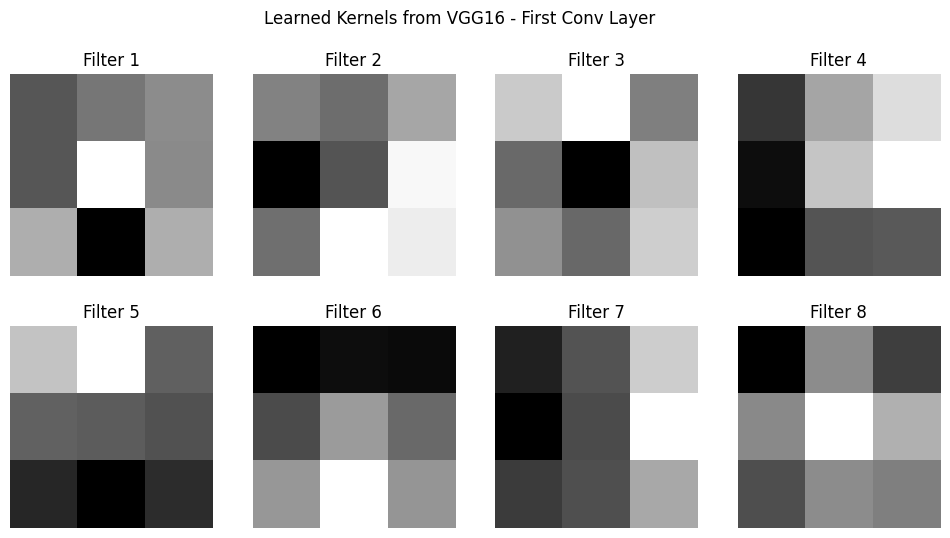


Observation:
- Many early layer kernels in VGG16 look like edge detectors, Gabor filters,
- and color blob detectors.
- Some filters closely resemble Sobel or Prewitt operators.


In [4]:
import torch
import torchvision.models as models
import matplotlib.pyplot as plt

# Load pretrained VGG16
model = models.vgg16(pretrained=True)
print("VGG16 loaded")

# Get first conv layer kernels (layer 0)
kernels = model.features[0].weight.data.cpu().numpy()  # shape: (64, 3, 3, 3)

# Visualize first 8 filters
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    # Take mean across RGB channels for visualization
    filt = np.mean(kernels[i], axis=0)
    plt.imshow(filt, cmap='gray')
    plt.title(f"Filter {i+1}")
    plt.axis('off')
plt.suptitle("Learned Kernels from VGG16 - First Conv Layer")
plt.show()

print("\nObservation:")
print("- Many early layer kernels in VGG16 look like edge detectors, Gabor filters,")
print("- and color blob detectors.")
print("- Some filters closely resemble Sobel or Prewitt operators.")

/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG16 loaded


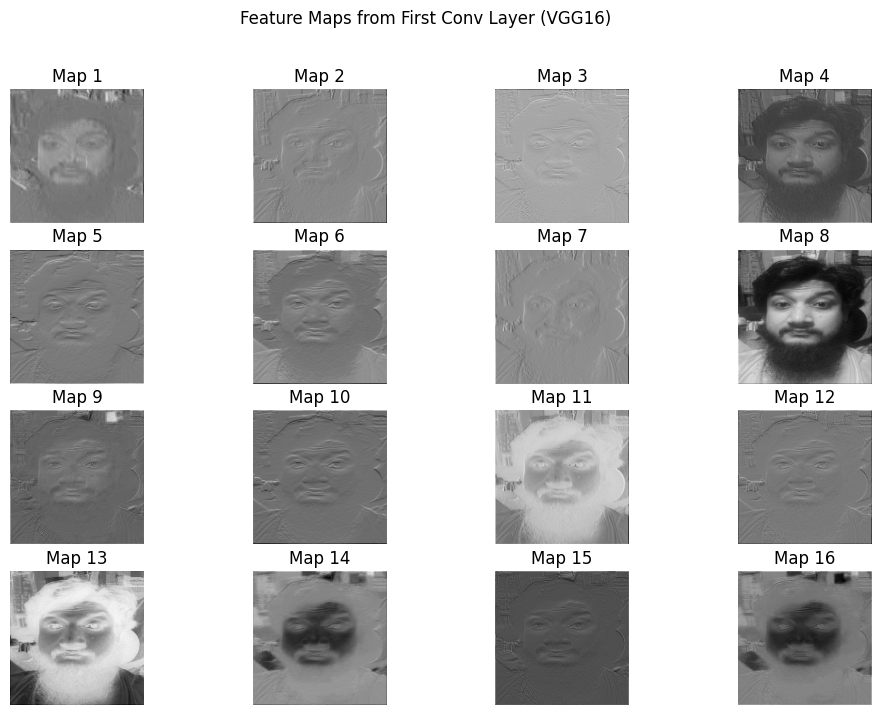

In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load pretrained VGG16
model = models.vgg16(pretrained=True)
model.eval()
print("VGG16 loaded")

# Load and preprocess image
image = Image.open("Nazmul.jpg").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

input_image = transform(image).unsqueeze(0)  # shape: (1, 3, 224, 224)

# Get first conv layer
first_layer = model.features[0]

# Apply filters (forward pass through first conv layer)
with torch.no_grad():
    output = first_layer(input_image)

# Convert output to numpy
feature_maps = output.squeeze(0).cpu().numpy()  # shape: (64, H, W)

# Visualize first 16 feature maps
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(feature_maps[i], cmap='gray')
    plt.title(f"Map {i+1}")
    plt.axis('off')

plt.suptitle("Feature Maps from First Conv Layer (VGG16)")
plt.show()